<a href="https://colab.research.google.com/github/JUST-ZARI/hotel-clv-prediction/blob/main/notebooks/04_eda_data_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Get the project files.
# Colab: clone the repo (development branch). Locally: run from the repository root.
import os, sys
if "google.colab" in sys.modules:
    !git clone -b development https://github.com/JUST-ZARI/hotel-clv-prediction.git
    %cd /content/hotel-clv-prediction
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: C:\Projects\hotel-clv-prediction-1


# Step 4: EDA + Data Quality Check on the Merged Dataset

**Unit of analysis.** Each record is one guest, identified by `guest_id` (created in Step 3).

**Target (defined in preprocessing).** Estimated CLV = historical booking value + repeat-booking indicators, where booking value = `adr × (stays_weekend_nights + stays_week_nights)` for bookings that were not cancelled. Monetary values are standardised to Kenyan Shillings (KSh) during preprocessing.

This notebook only *inspects* the data; nothing is changed or saved.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# low_memory=False: read each column in one pass (avoids the mixed-type warning on columns
# that are empty for one source)
df = pd.read_csv("data/processed/merged_dataset.csv", low_memory=False)
DS1, DS2 = "hotel_bookings_2015_2017", "hotel_reservations_2017_2018"
print("Shape:", df.shape)
df.head(3)

Shape: (155665, 34)


,guest_id,hotel_type,is_canceled,lead_time,arrival_year,arrival_month,arrival_day,stays_weekend_nights,stays_week_nights,num_adults,num_children,num_babies,meal_plan,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,room_type_reserved,assigned_room_type,booking_changes,deposit_type,agent_id,company_id,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_special_requests,reservation_status,reservation_status_date,source_dataset,booking_id
0,G-000001,Resort Hotel,0,342,2015,7,1,0,0,2,0,0.0,BB,PRT,Direct,Direct,0,0,0,C,C,3.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0,0,Check-Out,2015-07-01,hotel_bookings_2015_2017,NaN
1,G-000002,Resort Hotel,0,737,2015,7,1,0,0,2,0,0.0,BB,PRT,Direct,Direct,0,0,0,C,C,4.0,No Deposit,NaN,NaN,0.0,Transient,0.0,0,0,Check-Out,2015-07-01,hotel_bookings_2015_2017,NaN
2,G-000003,Resort Hotel,0,7,2015,7,1,0,1,1,0,0.0,BB,GBR,Direct,Direct,0,0,0,A,C,0.0,No Deposit,NaN,NaN,0.0,Transient,75.0,0,0,Check-Out,2015-07-02,hotel_bookings_2015_2017,NaN


## 1. Dtypes

In [3]:
df.dtypes

guest_id                              str
hotel_type                            str
is_canceled                         int64
lead_time                           int64
arrival_year                        int64
arrival_month                       int64
arrival_day                         int64
stays_weekend_nights                int64
stays_week_nights                   int64
num_adults                          int64
num_children                        int64
num_babies                        float64
meal_plan                             str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
room_type_reserved                    str
assigned_room_type                    str
booking_changes                   float64
deposit_type                          str
agent_id                          

## 2. Missing values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
company_id,148868,95.6
booking_id,119390,76.7
agent_id,52615,33.8
country,36763,23.6
assigned_room_type,36275,23.3
hotel_type,36275,23.3
booking_changes,36275,23.3
num_babies,36275,23.3
distribution_channel,36275,23.3
deposit_type,36275,23.3


Expect the 13 Dataset-1-only columns (`country`, `agent_id`, `deposit_type`, etc.) near ~23% missing (36,275 / 155,665 Dataset 2 rows) and `booking_id` near ~77% missing (119,390 / 155,665 Dataset 1 rows) — that's structural, from the merge, not bad data.

`guest_id` is never missing (checked in Step 3).

## 3. Duplicates

In [5]:
# guest_id is unique by design, so compare the booking details only
detail_cols = [c for c in df.columns if c not in ("guest_id", "booking_id", "source_dataset")]
d1, d2 = df[df.source_dataset == DS1], df[df.source_dataset == DS2]

print("Dataset 1 — rows identical to an earlier row:", d1.duplicated(subset=detail_cols).sum())
print("Dataset 2 — duplicate booking IDs:            ", d2["booking_id"].duplicated().sum())
print("Dataset 2 — same details, different booking ID:", d2.duplicated(subset=detail_cols).sum())
cross = d1[detail_cols].drop_duplicates().merge(d2[detail_cols].drop_duplicates(), how="inner")
print("Identical rows across the two sources:        ", len(cross))

Dataset 1 — rows identical to an earlier row: 31994
Dataset 2 — duplicate booking IDs:             0
Dataset 2 — same details, different booking ID: 10275


Identical rows across the two sources:         0


**Reading the duplicate counts**
- **Dataset 1** has no booking ID, so identical rows *might* be repeated records — or genuinely separate bookings with the same details (e.g. a group booking several identical rooms). Decide the policy in cleaning.
- **Dataset 2** rows with the same details still have **different booking IDs**, so they are different bookings and must **not** be removed.
- Never de-duplicate the merged data while ignoring `booking_id` — that would delete real Dataset 2 bookings.

## 4. Descriptive statistics

In [6]:
df.describe()

,is_canceled,lead_time,arrival_year,arrival_month,arrival_day,stays_weekend_nights,stays_week_nights,num_adults,num_children,num_babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent_id,company_id,days_in_waiting_list,adr,required_car_parking_spaces,total_special_requests
count,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,155665.000000,119390.000000,155665.000000,155665.000000,155665.000000,119390.000000,103050.000000,6797.000000,119390.000000,155665.000000,155665.000000,155665.000000
mean,0.360447,99.635332,2016.544291,6.755494,15.751344,0.900363,2.431324,1.853737,0.104211,0.007949,0.030450,0.072258,0.140899,0.221124,86.693382,189.266735,2.321149,102.202207,0.055170,0.582617
std,0.480132,102.675540,0.955523,3.107693,8.771820,0.971556,1.809001,0.565750,0.399512,0.097436,0.171823,0.760996,1.561051,0.652306,110.774548,131.655015,17.594721,47.393049,0.230914,0.791535
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,4.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,73.000000,0.000000,0.000000
50%,0.000000,66.000000,2016.000000,7.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,153.000000,2017.000000,9.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,125.000000,0.000000,1.000000
max,1.000000,737.000000,2018.000000,12.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.describe(include='object')

C:\Users\zaria\AppData\Local\Temp\ipykernel_43696\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,guest_id,hotel_type,meal_plan,country,market_segment,distribution_channel,room_type_reserved,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,source_dataset,booking_id
count,155665,119390,155665,118902,155665,119390,155665,119390,119390,119390,119390,119390,155665,36275
unique,155665,2,5,177,8,5,10,12,3,4,3,926,2,36275
top,G-000001,City Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,hotel_bookings_2015_2017,INN00001
freq,1,79330,120145,48590,79691,97870,114124,74053,104641,89613,75166,1461,119390,1


## 5. Univariate analysis — ADR and lead_time distributions

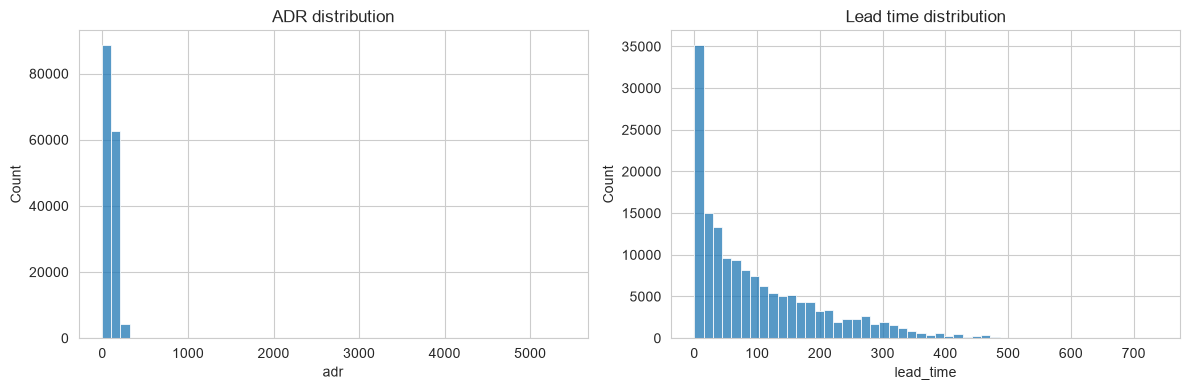

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['adr'], bins=50, ax=axes[0])
axes[0].set_title('ADR distribution')
sns.histplot(df['lead_time'], bins=50, ax=axes[1])
axes[1].set_title('Lead time distribution')
plt.tight_layout()
plt.show()

## 6. Outlier check — ADR and lead_time (IQR method)

In [9]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['adr', 'lead_time']:
    low, high = iqr_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: IQR bounds [{low:.1f}, {high:.1f}] -> {n_outliers} outliers "
          f"({n_outliers/len(df)*100:.1f}%), max value = {df[col].max()}")

adr: IQR bounds [-5.0, 203.0] -> 5133 outliers (3.3%), max value = 5400.0
lead_time: IQR bounds [-184.5, 355.5] -> 3873 outliers (2.5%), max value = 737


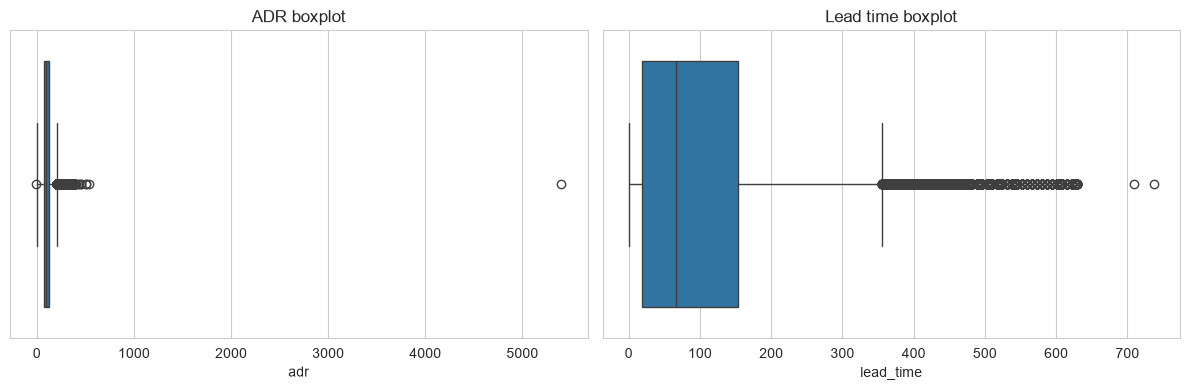

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['adr'], ax=axes[0])
axes[0].set_title('ADR boxplot')
sns.boxplot(x=df['lead_time'], ax=axes[1])
axes[1].set_title('Lead time boxplot')
plt.tight_layout()
plt.show()

In [11]:
# quick look at the most extreme ADR rows - is it a data entry error or a real luxury booking?
df.nlargest(5, 'adr')[['adr', 'hotel_type', 'source_dataset', 'num_adults', 'room_type_reserved']]

,adr,hotel_type,source_dataset,num_adults,room_type_reserved
48515,5400.0,City Hotel,hotel_bookings_2015_2017,2,A
152504,540.0,NaN,hotel_reservations_2017_2018,2,A
111403,510.0,City Hotel,hotel_bookings_2015_2017,1,A
15083,508.0,Resort Hotel,hotel_bookings_2015_2017,2,A
103912,451.5,City Hotel,hotel_bookings_2015_2017,2,E


## 7. Bivariate — is_canceled vs lead_time and ADR

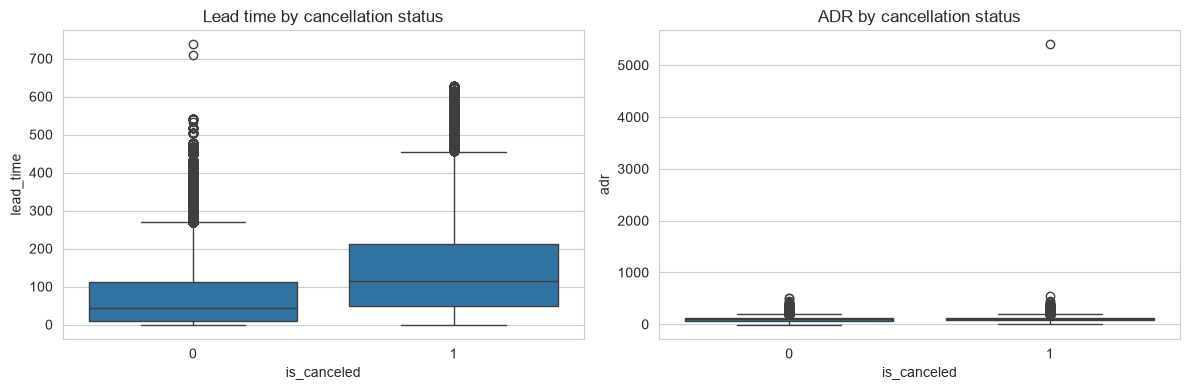

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='is_canceled', y='lead_time', ax=axes[0])
axes[0].set_title('Lead time by cancellation status')
sns.boxplot(data=df, x='is_canceled', y='adr', ax=axes[1])
axes[1].set_title('ADR by cancellation status')
plt.tight_layout()
plt.show()

## 8. Correlation — numeric features

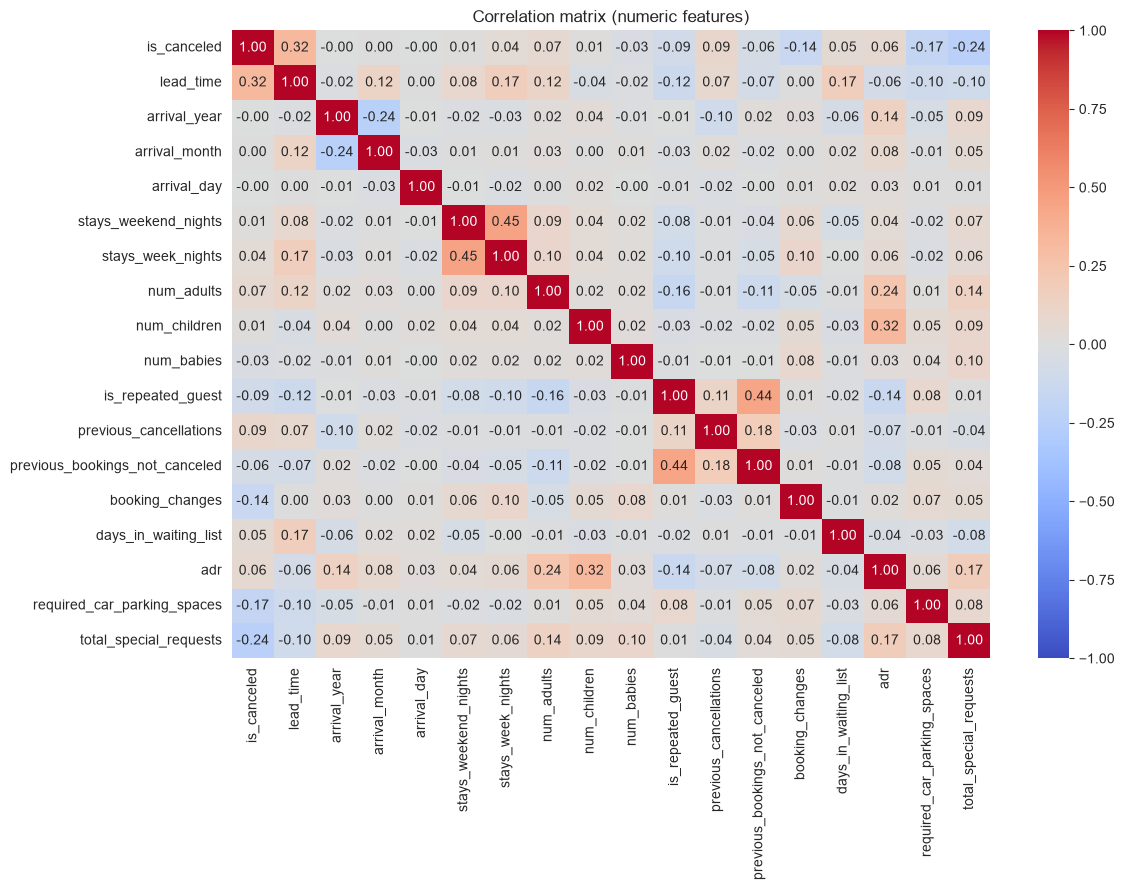

In [13]:
# agent_id / company_id are codes, not quantities — their correlations are meaningless
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['agent_id', 'company_id'])
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

In [14]:
# strongest correlations with is_canceled specifically, since that feeds CLV (non-cancelled bookings only)
corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

lead_time                         0.321862
total_special_requests           -0.239543
required_car_parking_spaces      -0.172758
booking_changes                  -0.144381
previous_cancellations            0.091878
is_repeated_guest                -0.088812
num_adults                        0.065880
adr                               0.062629
previous_bookings_not_canceled   -0.058015
days_in_waiting_list              0.054186
stays_week_nights                 0.039281
num_babies                       -0.032491
stays_weekend_nights              0.013063
num_children                      0.011414
arrival_day                      -0.001956
arrival_year                     -0.001787
arrival_month                     0.001464
Name: is_canceled, dtype: float64

## 9. Source comparison
The sources are different hotels and periods, so compare them side by side before treating them as one population.

In [15]:
df["total_nights"] = df["stays_weekend_nights"] + df["stays_week_nights"]
df["total_guests"] = df["num_adults"] + df["num_children"] + df["num_babies"].fillna(0)

g = df.groupby("source_dataset")
pd.DataFrame({
    "records": g.size(),
    "arrival from": g.apply(lambda s: f"{s.arrival_year.min()}-{s[s.arrival_year == s.arrival_year.min()].arrival_month.min():02d}"),
    "arrival to": g.apply(lambda s: f"{s.arrival_year.max()}-{s[s.arrival_year == s.arrival_year.max()].arrival_month.max():02d}"),
    "ADR median": g["adr"].median(),
    "ADR mean": g["adr"].mean().round(1),
    "nights mean": g["total_nights"].mean().round(2),
    "lead time median": g["lead_time"].median(),
    "cancelled %": (g["is_canceled"].mean() * 100).round(1),
    "repeat guest %": (g["is_repeated_guest"].mean() * 100).round(1),
}).T

source_dataset,hotel_bookings_2015_2017,hotel_reservations_2017_2018
records,119390,36275
arrival from,2015-07,2017-07
arrival to,2017-08,2018-12
ADR median,94.575,99.45
ADR mean,101.8,103.4
nights mean,3.43,3.02
lead time median,69.0,57.0
cancelled %,37.0,32.8
repeat guest %,3.2,2.6


ADR levels are similar (medians within about 5%). Dataset 1 is in **EUR** (Portuguese hotels). Dataset 2 does not state its currency; it is **assumed EUR** because its price level matches. Both are converted to **KSh** in preprocessing using one documented exchange rate.

## 10. Category consistency
The same meaning must use the same label for every record (Dataset 2's values were translated in Step 2).

In [16]:
for col in ["meal_plan", "market_segment", "room_type_reserved"]:
    by_source = df.groupby("source_dataset")[col].apply(lambda s: set(s.dropna()))
    only_ds2 = by_source[DS2] - by_source[DS1]
    print(f"{col}: {df[col].nunique()} values | only in Dataset 2: {sorted(only_ds2) or 'none'}")

meal_plan: 5 values | only in Dataset 2: none
market_segment: 8 values | only in Dataset 2: none


room_type_reserved: 10 values | only in Dataset 2: none


`meal_plan`, `market_segment` and `room_type_reserved` now share one vocabulary across the combined dataset (room types: `Room_Type 1–7` → `A–G`, see Step 2).

## 11. Arrival date validity

In [17]:
arrival = pd.to_datetime(dict(year=df.arrival_year, month=df.arrival_month, day=df.arrival_day), errors="coerce")
invalid = df[arrival.isna()]
print("Invalid arrival dates:", len(invalid))
invalid.groupby(["source_dataset", "arrival_year", "arrival_month", "arrival_day"]).size().rename("records")

Invalid arrival dates: 37


source_dataset                arrival_year  arrival_month  arrival_day
hotel_reservations_2017_2018  2018          2              29             37
Name: records, dtype: int64

29 February 2018 does not exist (2018 is not a leap year) — a known fault in Dataset 2. Fix or drop in cleaning.

## 12. Impossible or suspicious bookings

In [18]:
checks = {
    "0 nights": df["total_nights"] == 0,
    "0 guests": df["total_guests"] == 0,
    "0 adults": df["num_adults"] == 0,
    "ADR = 0": df["adr"] == 0,
    "ADR < 0": df["adr"] < 0,
    "ADR > 1,000": df["adr"] > 1000,
}
pd.DataFrame({name: df[mask].groupby("source_dataset").size() for name, mask in checks.items()}).fillna(0).astype(int).T

source_dataset,hotel_bookings_2015_2017,hotel_reservations_2017_2018
0 nights,715,78
0 guests,180,0
0 adults,403,139
ADR = 0,1959,545
ADR < 0,1,0
"ADR > 1,000",1,0


Zero-night, zero-guest and negative/extreme-price records cannot produce a meaningful booking value. `ADR = 0` is usually a complimentary stay (check `market_segment == 'Complementary'`). Handle all of these in cleaning.

## 13. Estimated CLV — first look at the booking value
Preview only (original currency, no cleaning). Booking value = `adr × total_nights` for bookings that were **not** cancelled; cancelled bookings contribute 0.

source_dataset  hotel_bookings_2015_2017  hotel_reservations_2017_2018
count                           119390.0                       36275.0
mean                               217.7                         194.4
std                                305.8                         208.8
min                                -63.8                           0.0
25%                                  0.0                           0.0
50%                                119.0                         158.1
75%                                323.0                         307.8
max                               7590.0                        2389.0

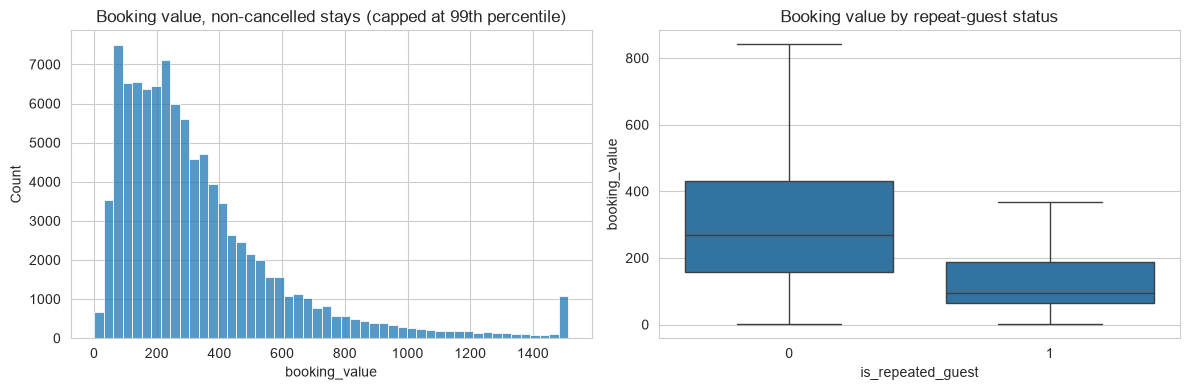

In [19]:
df["booking_value"] = np.where(df["is_canceled"] == 0, df["adr"] * df["total_nights"], 0.0)

print(df.groupby("source_dataset")["booking_value"].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
kept = df[df["booking_value"] > 0]
sns.histplot(kept["booking_value"].clip(upper=kept["booking_value"].quantile(0.99)), bins=50, ax=axes[0])
axes[0].set_title("Booking value, non-cancelled stays (capped at 99th percentile)")
sns.boxplot(data=kept, x="is_repeated_guest", y="booking_value", ax=axes[1], showfliers=False)
axes[1].set_title("Booking value by repeat-guest status")
plt.tight_layout()
plt.show()

## 14. Summary — carry into cleaning & preprocessing
1. **Duplicates:** decide the policy for Dataset 1 identical rows; keep Dataset 2 rows (distinct booking IDs).
2. **Invalid dates:** 29 Feb 2018 records in Dataset 2.
3. **Impossible bookings:** 0 nights, 0 guests, negative/extreme ADR, ADR = 0.
4. **Missing values:** `country`, `agent_id`, `company_id` in Dataset 1; structural NaNs in source-only columns.
5. **Post-outcome columns:** `reservation_status`, `reservation_status_date`, `assigned_room_type`, `booking_changes`, `days_in_waiting_list` are only known after the booking — decide which may be model features.
6. **Data types:** restore integer/date types after loading (CSV turns them into floats/text).
7. **One combined dataset:** values that only one source recorded are filled from the combined data (most common value among guests in the same market segment), not left as a separate category.
8. **Target:** build Estimated CLV = booking value + repeat-booking indicators, converted to **KSh**.